Imports & Configuration

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import radians, sin, cos, sqrt, atan2

# Sklearn
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, precision_recall_curve,
                              ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight



In [6]:
# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential


In [7]:

from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [8]:
# Sauvegarde
import joblib
import warnings
warnings.filterwarnings('ignore')

# Config
plt.style.use('seaborn-v0_8-darkgrid')
RANDOM_STATE = 42

Chargement & Première Inspection

In [9]:
# === 1.1 Chargement ===
train_df = pd.read_csv('../data/fraudTrain.csv', index_col=0)
test_df  = pd.read_csv('../data/fraudTest.csv',  index_col=0)

print(f"Train : {train_df.shape} | Test : {test_df.shape}")
train_df.head(3)

Train : (1296675, 22) | Test : (555719, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0


<class 'pandas.core.frame.DataFrame'>
Index: 1296675 entries, 0 to 1296674
Data columns (total 22 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   trans_date_trans_time  1296675 non-null  object 
 1   cc_num                 1296675 non-null  int64  
 2   merchant               1296675 non-null  object 
 3   category               1296675 non-null  object 
 4   amt                    1296675 non-null  float64
 5   first                  1296675 non-null  object 
 6   last                   1296675 non-null  object 
 7   gender                 1296675 non-null  object 
 8   street                 1296675 non-null  object 
 9   city                   1296675 non-null  object 
 10  state                  1296675 non-null  object 
 11  zip                    1296675 non-null  int64  
 12  lat                    1296675 non-null  float64
 13  long                   1296675 non-null  float64
 14  city_pop               

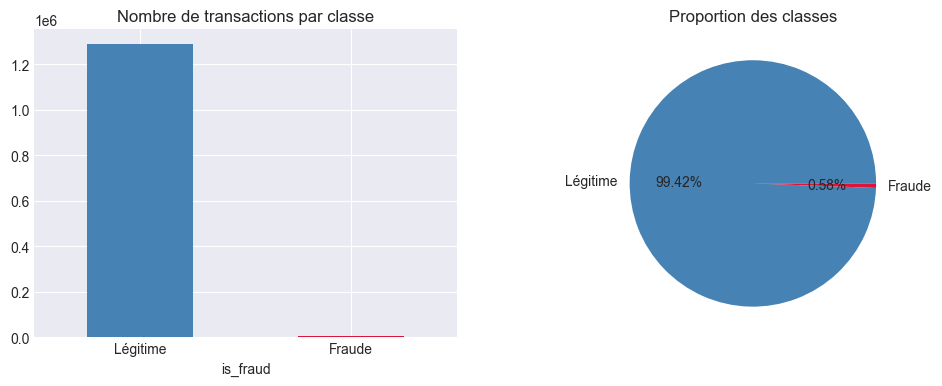

In [11]:


# === 1.2 Infos générales ===
train_df.info()
train_df.describe()

# === 1.3 Valeurs manquantes ===
print(train_df.isnull().sum())

# === 1.4 Distribution de la cible ===
fraud_counts = train_df['is_fraud'].value_counts()
fraud_pct    = train_df['is_fraud'].value_counts(normalize=True) * 100

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fraud_counts.plot(kind='bar', ax=ax[0], color=['steelblue','crimson'])
ax[0].set_title('Nombre de transactions par classe')
ax[0].set_xticklabels(['Légitime', 'Fraude'], rotation=0)

ax[1].pie(fraud_pct, labels=['Légitime', 'Fraude'],
          autopct='%1.2f%%', colors=['steelblue','crimson'])
ax[1].set_title('Proportion des classes')
plt.savefig('../outputs/figures/class_distribution.png', dpi=150)
plt.show()

Analyse Exploratoire (EDA)

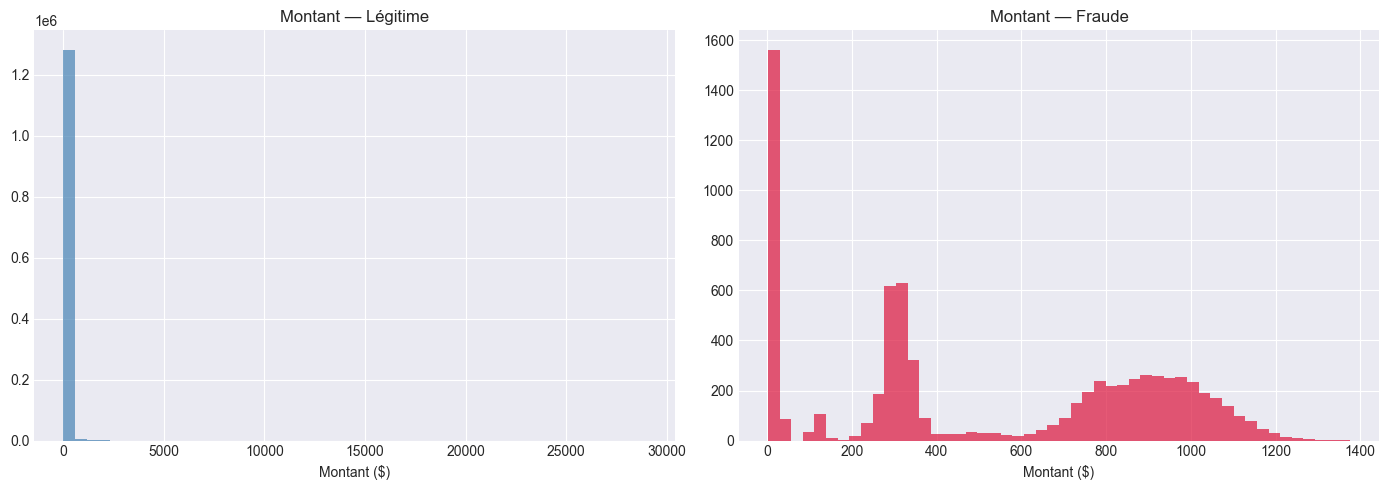

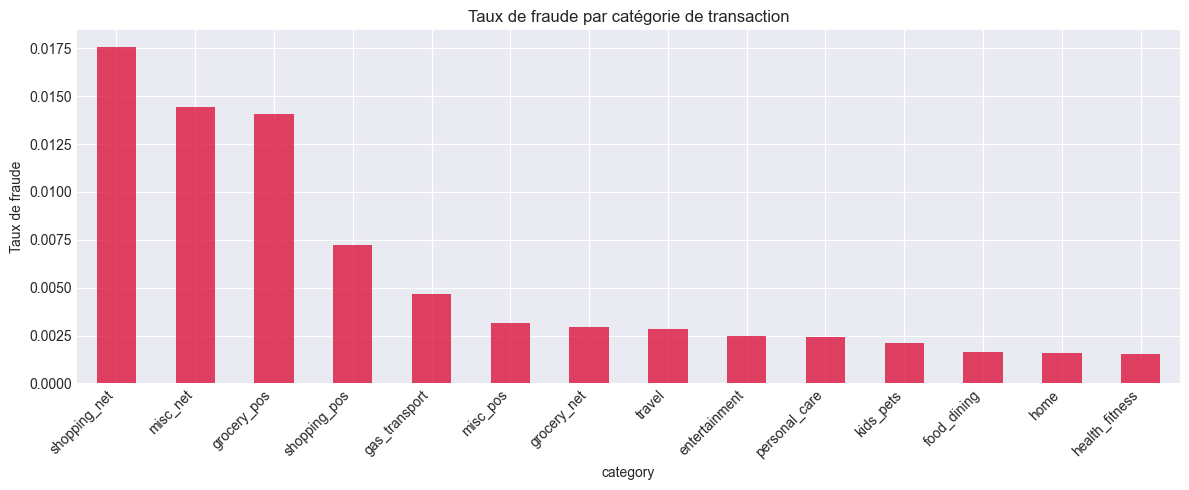

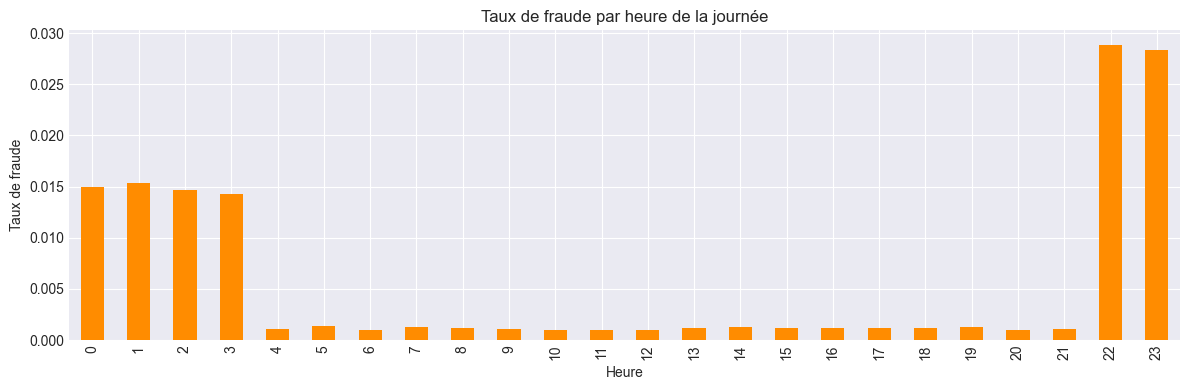

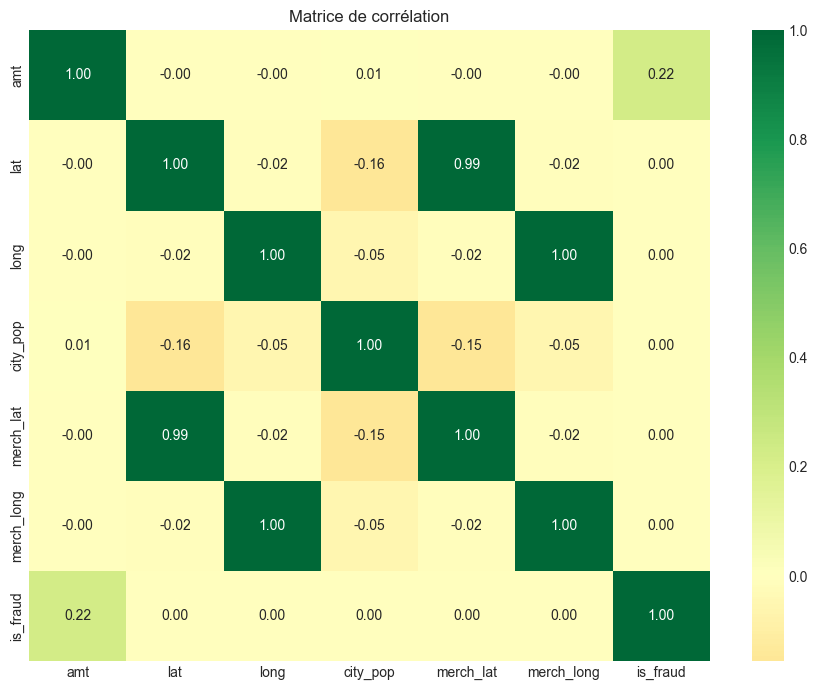

In [12]:
# === 2.1 Distribution du montant par classe ===
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, (label, color) in enumerate(zip([0, 1], ['steelblue', 'crimson'])):
    subset = train_df[train_df['is_fraud'] == label]['amt']
    axes[i].hist(subset, bins=50, color=color, alpha=0.7)
    axes[i].set_title(f"Montant — {'Fraude' if label else 'Légitime'}")
    axes[i].set_xlabel('Montant ($)')
plt.tight_layout()
plt.savefig('../outputs/figures/amount_distribution.png', dpi=150)

# === 2.2 Fraude par catégorie ===
fraud_by_cat = (train_df.groupby('category')['is_fraud']
                .mean().sort_values(ascending=False))
plt.figure(figsize=(12, 5))
fraud_by_cat.plot(kind='bar', color='crimson', alpha=0.8)
plt.title('Taux de fraude par catégorie de transaction')
plt.ylabel('Taux de fraude')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../outputs/figures/fraud_by_category.png', dpi=150)
plt.show()

# === 2.3 Fraude par heure de la journée ===
train_df['hour_temp'] = pd.to_datetime(
    train_df['trans_date_trans_time']).dt.hour
fraud_by_hour = train_df.groupby('hour_temp')['is_fraud'].mean()
plt.figure(figsize=(12, 4))
fraud_by_hour.plot(kind='bar', color='darkorange')
plt.title('Taux de fraude par heure de la journée')
plt.xlabel('Heure')
plt.ylabel('Taux de fraude')
plt.tight_layout()
plt.savefig('../outputs/figures/fraud_by_hour.png', dpi=150)
plt.show()
train_df.drop(columns=['hour_temp'], inplace=True)

# === 2.4 Heatmap de corrélation (features numériques) ===
num_cols = ['amt', 'lat', 'long', 'city_pop',
            'merch_lat', 'merch_long', 'is_fraud']
plt.figure(figsize=(9, 7))
sns.heatmap(train_df[num_cols].corr(), annot=True,
            fmt='.2f', cmap='RdYlGn', center=0)
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.savefig('../outputs/figures/correlation_matrix.png', dpi=150)
plt.show()

Prétraitement & Feature Engineering

In [13]:
# === 3.1 Fusion train + test pour un prétraitement uniforme ===
train_df['_split'] = 'train'
test_df['_split']  = 'test'
df = pd.concat([train_df, test_df], ignore_index=True)

# === 3.2 Suppression des colonnes inutiles ===
cols_to_drop = ['first', 'last', 'street', 'trans_num',
                'cc_num', 'zip', 'city', 'unix_time']
df.drop(columns=cols_to_drop, inplace=True)

# === 3.3 Features temporelles ===
df['trans_dt']   = pd.to_datetime(df['trans_date_trans_time'])
df['hour']       = df['trans_dt'].dt.hour
df['day_of_week']= df['trans_dt'].dt.dayofweek
df['month']      = df['trans_dt'].dt.month
df['is_night']   = df['hour'].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)
df.drop(columns=['trans_date_trans_time', 'trans_dt'], inplace=True)

# === 3.4 Âge du client ===
df['dob'] = pd.to_datetime(df['dob'])
ref_date  = pd.Timestamp('2020-01-01')
df['age'] = ((ref_date - df['dob']).dt.days // 365).astype(int)
df.drop(columns=['dob'], inplace=True)

# === 3.5 Distance géographique Haversine ===
def haversine(lat1, lon1, lat2, lon2):
    R = 6371
    dlat = radians(lat2 - lat1)
    dlon = radians(lon2 - lon1)
    a = (sin(dlat/2)**2 +
         cos(radians(lat1)) * cos(radians(lat2)) * sin(dlon/2)**2)
    return R * 2 * atan2(sqrt(a), sqrt(1 - a))

df['distance_km'] = df.apply(
    lambda r: haversine(r['lat'], r['long'],
                        r['merch_lat'], r['merch_long']), axis=1)
df.drop(columns=['lat', 'long', 'merch_lat', 'merch_long'], inplace=True)

# === 3.6 Encodage des variables catégorielles ===

# gender → Label Encoding simple
df['gender'] = df['gender'].map({'F': 0, 'M': 1})

# category → One-Hot Encoding
df = pd.get_dummies(df, columns=['category'], drop_first=False)

# state, job, merchant → Target Encoding
#   (calculé UNIQUEMENT sur le train pour éviter le data leakage)
train_mask = df['_split'] == 'train'

for col in ['state', 'job', 'merchant']:
    target_map = (df[train_mask]
                  .groupby(col)['is_fraud']
                  .mean()
                  .to_dict())
    global_mean = df[train_mask]['is_fraud'].mean()
    df[col] = df[col].map(target_map).fillna(global_mean)

# === 3.7 Ré-séparation train / test ===
train_clean = df[df['_split'] == 'train'].drop(columns=['_split'])
test_clean  = df[df['_split'] == 'test'].drop(columns=['_split'])

X_train = train_clean.drop(columns=['is_fraud'])
y_train = train_clean['is_fraud'].astype(int)
X_test  = test_clean.drop(columns=['is_fraud'])
y_test  = test_clean['is_fraud'].astype(int)

print(f"Features finales : {X_train.shape[1]}")
print(X_train.columns.tolist())

# === 3.8 Normalisation (fit sur train uniquement) ===
num_features = ['amt', 'city_pop', 'distance_km', 'age',
                'hour', 'day_of_week', 'month',
                'state', 'job', 'merchant']

scaler = StandardScaler()
X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features]  = scaler.transform(X_test[num_features])

# Sauvegarde du scaler pour la plateforme web
joblib.dump(scaler, '../models/scaler.pkl')
print("✅ Scaler sauvegardé")

Features finales : 26
['merchant', 'amt', 'gender', 'state', 'city_pop', 'job', 'hour', 'day_of_week', 'month', 'is_night', 'age', 'distance_km', 'category_entertainment', 'category_food_dining', 'category_gas_transport', 'category_grocery_net', 'category_grocery_pos', 'category_health_fitness', 'category_home', 'category_kids_pets', 'category_misc_net', 'category_misc_pos', 'category_personal_care', 'category_shopping_net', 'category_shopping_pos', 'category_travel']
✅ Scaler sauvegardé


Modèles Classiques (Baseline)


  Régression Logistique
              precision    recall  f1-score   support

    Légitime       1.00      0.90      0.95    553574
      Fraude       0.03      0.76      0.06      2145

    accuracy                           0.90    555719
   macro avg       0.51      0.83      0.50    555719
weighted avg       1.00      0.90      0.94    555719

  AUC-ROC : 0.9342


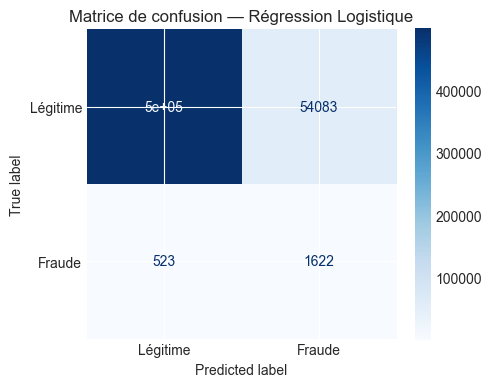


  Arbre de Décision
              precision    recall  f1-score   support

    Légitime       1.00      0.97      0.98    553574
      Fraude       0.08      0.71      0.14      2145

    accuracy                           0.97    555719
   macro avg       0.54      0.84      0.56    555719
weighted avg       1.00      0.97      0.98    555719

  AUC-ROC : 0.8139


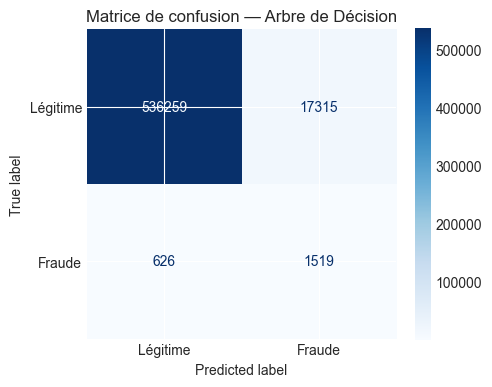


  Random Forest
              precision    recall  f1-score   support

    Légitime       1.00      1.00      1.00    553574
      Fraude       0.95      0.50      0.66      2145

    accuracy                           1.00    555719
   macro avg       0.97      0.75      0.83    555719
weighted avg       1.00      1.00      1.00    555719

  AUC-ROC : 0.9621


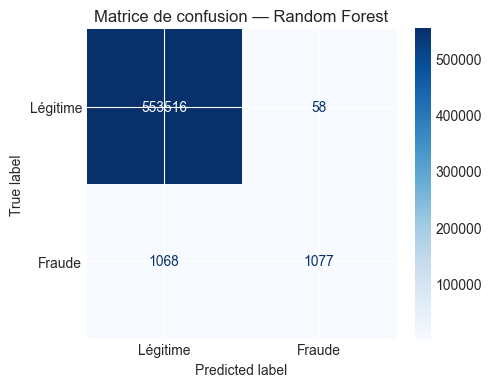

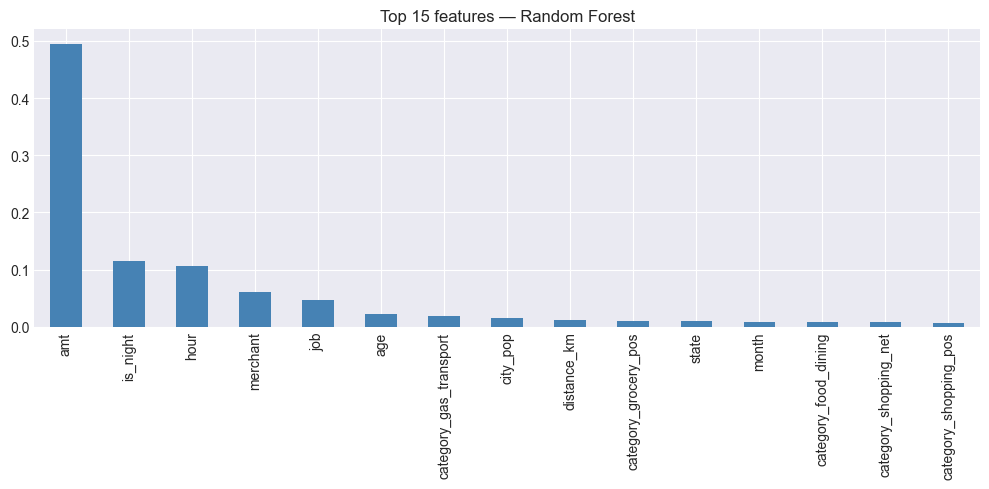

In [14]:
# === Fonction d'évaluation réutilisable ===
def evaluate_model(name, y_true, y_pred, y_proba=None):
    print(f"\n{'='*50}")
    print(f"  {name}")
    print('='*50)
    print(classification_report(y_true, y_pred,
                                 target_names=['Légitime', 'Fraude']))
    if y_proba is not None:
        auc = roc_auc_score(y_true, y_proba)
        print(f"  AUC-ROC : {auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm,
               display_labels=['Légitime', 'Fraude'])
    fig, ax = plt.subplots(figsize=(5, 4))
    disp.plot(ax=ax, cmap='Blues')
    ax.set_title(f'Matrice de confusion — {name}')
    plt.tight_layout()
    plt.savefig(f'../outputs/figures/cm_{name.replace(" ","_")}.png',
                dpi=150)
    plt.show()

# === 4.1 Régression Logistique ===
lr = LogisticRegression(class_weight='balanced',
                         max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)
evaluate_model("Régression Logistique",
               y_test, lr.predict(X_test),
               lr.predict_proba(X_test)[:, 1])

# === 4.2 Arbre de Décision ===
dt = DecisionTreeClassifier(class_weight='balanced',
                              max_depth=10, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
evaluate_model("Arbre de Décision",
               y_test, dt.predict(X_test),
               dt.predict_proba(X_test)[:, 1])

# === 4.3 Random Forest ===
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced',
                             n_jobs=-1, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
evaluate_model("Random Forest",
               y_test, rf.predict(X_test),
               rf.predict_proba(X_test)[:, 1])

# Importance des features (Random Forest)
feat_imp = pd.Series(rf.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)[:15]
plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue')
plt.title('Top 15 features — Random Forest')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance_rf.png', dpi=150)
plt.show()

Modèle Principal : MLP (TensorFlow/Keras)

Class weights → Légitime: 0.50 | Fraude: 86.38


Model: "MLP_FraudDetection"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         6,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,665 (194.00 KB)

 Trainable params: 48,897 (191.00 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/50
2151/2153 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - auc: 0.9353 - loss: 0.3165 - precision: 0.0361 - recall: 0.8648
Epoch 1: val_recall improved from -inf to 0.92145, saving model to ../models/mlp_model.keras
2153/2153 ━━━━━━━━━━━━━━━━━━━━ 34s 14ms/step - auc: 0.9353 - loss: 0.3164 - precision: 0.0361 - recall: 0.8649 - val_auc: 0.9866 - val_loss: 0.0997 - val_precision: 0.1166 - val_recall: 0.9214
Epoch 2/50
2153/2153 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - auc: 0.9860 - loss: 0.1452 - precision: 0.0888 - recall: 0.9466
Epoch 2: val_recall improved from 0.92145 to 0.93027, saving model to ../models/mlp_model.keras
2153/2153 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - auc: 0.9860 - loss: 0.1452 - precision: 0.0888 - recall: 0.9466 - val_auc: 0.9928 - val_loss: 0.0840 - val_precision: 0.1631 - val_recall: 0.9303
Epoch 3/50
2150/2153 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - auc: 0.9904 - loss: 0.1227 - precision: 0.1111 - recall: 0.9563
Epoch 3: val_recall improved from 0.93027 to 0.95940, saving m

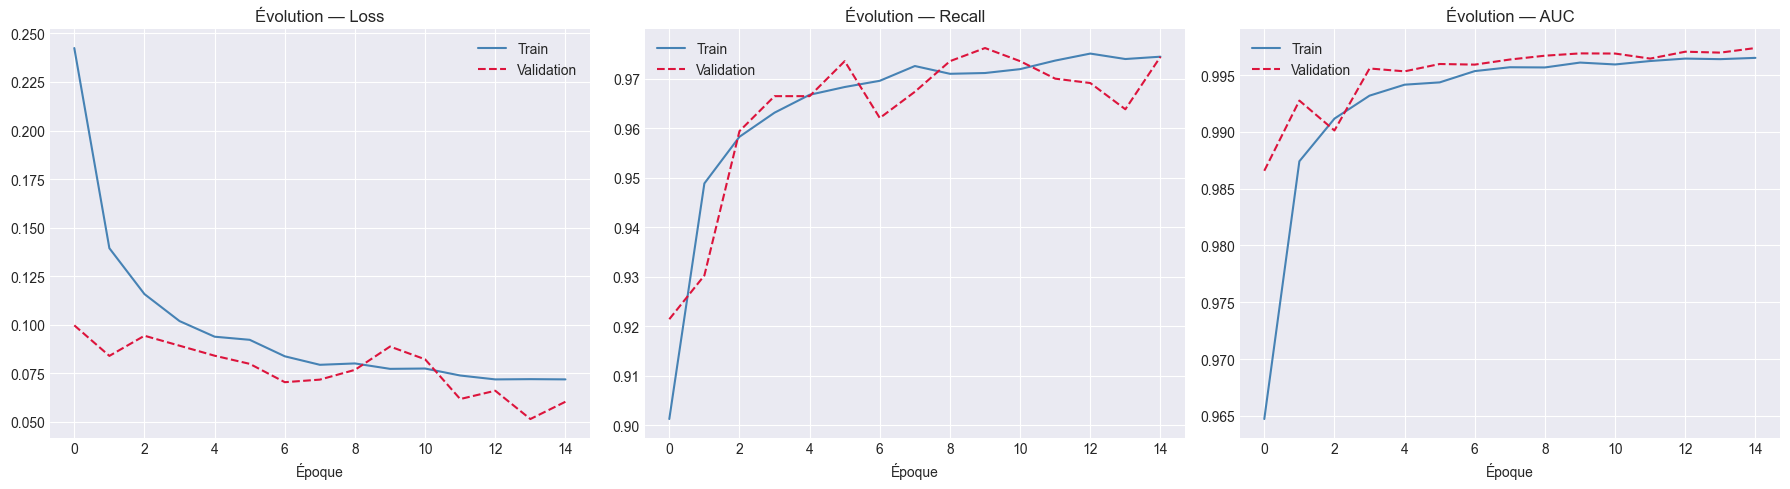

17367/17367 ━━━━━━━━━━━━━━━━━━━━ 30s 2ms/step

  MLP (réseau de neurones)
              precision    recall  f1-score   support

    Légitime       1.00      0.97      0.98    553574
      Fraude       0.10      0.95      0.18      2145

    accuracy                           0.97    555719
   macro avg       0.55      0.96      0.58    555719
weighted avg       1.00      0.97      0.98    555719

  AUC-ROC : 0.9931


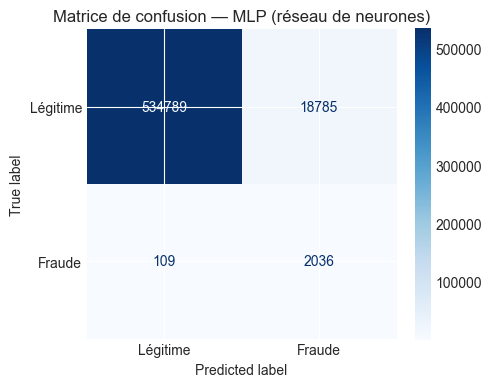

In [16]:
# === 5.1 Conversion en arrays numpy ===
X_tr = X_train.values.astype('float32')
X_te = X_test.values.astype('float32')
y_tr = y_train.values.astype('float32')
y_te = y_test.values.astype('float32')

# === 5.2 Class weights ===
weights = compute_class_weight('balanced',
                                classes=np.array([0, 1]), y=y_tr)
class_weight = {0: weights[0], 1: weights[1]}
print(f"Class weights → Légitime: {weights[0]:.2f} | Fraude: {weights[1]:.2f}")

# === 5.3 Architecture MLP ===
n_features = X_tr.shape[1]

model = Sequential([
    Dense(256, activation='relu', input_shape=(n_features,)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation='relu'),
    Dropout(0.2),

    Dense(1, activation='sigmoid')
], name='MLP_FraudDetection')

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=[
        tf.keras.metrics.Recall(name='recall'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.AUC(name='auc')
    ]
)

model.summary()

# === 5.4 Callbacks ===
callbacks = [
    EarlyStopping(monitor='val_recall', patience=5,
                  mode='max', restore_best_weights=True,
                  verbose=1),
    ModelCheckpoint('../models/mlp_model.keras',
                    monitor='val_recall', mode='max',
                    save_best_only=True, verbose=1)
]

# === 5.5 Entraînement ===
history = model.fit(
    X_tr, y_tr,
    epochs=50,
    batch_size=512,
    validation_split=0.15,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=1
)

# === 5.6 Courbes d'apprentissage ===
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, metric, title in zip(
        axes,
        ['loss', 'recall', 'auc'],
        ['Loss', 'Recall', 'AUC']):
    ax.plot(history.history[metric], label='Train', color='steelblue')
    ax.plot(history.history[f'val_{metric}'], label='Validation',
            color='crimson', linestyle='--')
    ax.set_title(f'Évolution — {title}')
    ax.set_xlabel('Époque')
    ax.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/learning_curves_mlp.png', dpi=150)
plt.show()

# === 5.7 Évaluation MLP ===
y_proba_mlp = model.predict(X_te).flatten()
y_pred_mlp  = (y_proba_mlp >= 0.5).astype(int)
evaluate_model("MLP (réseau de neurones)",
               y_te, y_pred_mlp, y_proba_mlp)

Comparaison finale des modèles
python

17367/17367 ━━━━━━━━━━━━━━━━━━━━ 37s 2ms/step
                       Recall  Precision  F1-Score  AUC-ROC
Random Forest          0.5021     0.9489    0.6567   0.9621
MLP                    0.9492     0.0978    0.1773   0.9931
Arbre de Décision      0.7082     0.0807    0.1448   0.8139
Régression Logistique  0.7562     0.0291    0.0561   0.9342


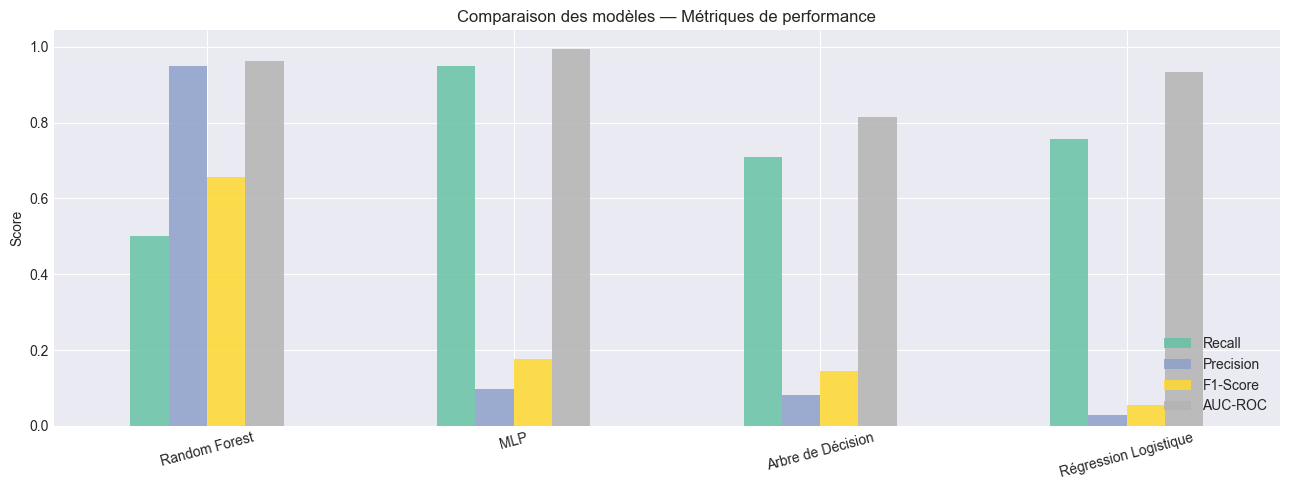

In [18]:
# === Tableau comparatif ===
from sklearn.metrics import f1_score, recall_score, precision_score

results = {}
models_info = {
    'Régression Logistique': (lr, 'sklearn'),
    'Arbre de Décision':     (dt, 'sklearn'),
    'Random Forest':         (rf, 'sklearn'),
    'MLP':                   (model, 'keras')
}

for name, (m, mtype) in models_info.items():
    if mtype == 'sklearn':
        preds = m.predict(X_te)
        proba = m.predict_proba(X_te)[:, 1]
    else:
        proba = m.predict(X_te).flatten()
        preds = (proba >= 0.5).astype(int)

    results[name] = {
        'Recall':    round(recall_score(y_te, preds), 4),
        'Precision': round(precision_score(y_te, preds), 4),
        'F1-Score':  round(f1_score(y_te, preds), 4),
        'AUC-ROC':   round(roc_auc_score(y_te, proba), 4)
    }

results_df = pd.DataFrame(results).T.sort_values('F1-Score', ascending=False)
print(results_df.to_string())

# Visualisation comparaison
results_df.plot(kind='bar', figsize=(13, 5), colormap='Set2', alpha=0.85)
plt.title('Comparaison des modèles — Métriques de performance')
plt.ylabel('Score')
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/model_comparison.png', dpi=150)
plt.show()

# Sauvegarde du tableau
results_df.to_csv('../outputs/reports/model_comparison.csv')

Sauvegarde finale pour la plateforme web

In [19]:
# === Sauvegarde de tout ce qu'il faut pour l'API ===

# Modèle Keras
model.save('../models/mlp_model.keras')

# Scaler (déjà sauvegardé en section 3)
# joblib.dump(scaler, '../models/scaler.pkl')

# Liste ordonnée des features (CRITIQUE pour l'API)
feature_columns = X_train.columns.tolist()
joblib.dump(feature_columns, '../models/feature_columns.pkl')

# Encodeurs (mappings target encoding)
target_enc_maps = {}
for col in ['state', 'job', 'merchant']:
    target_enc_maps[col] = (df[train_mask]
                            .groupby(col)['is_fraud']
                            .mean().to_dict())
joblib.dump(target_enc_maps, '../models/encoders.pkl')

print("✅ Tous les artefacts sauvegardés dans /models/")
print(f"   → mlp_model.h5       ({n_features} features)")
print(f"   → scaler.pkl")
print(f"   → feature_columns.pkl")
print(f"   → encoders.pkl")

✅ Tous les artefacts sauvegardés dans /models/
   → mlp_model.h5       (26 features)
   → scaler.pkl
   → feature_columns.pkl
   → encoders.pkl
